In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("default")  # force white background regardless of IDE theme

BLUE = "#00008B"
DATA_PATH = "data/twitter_nhb.csv"

In [11]:
# Load only the columns needed for descriptives
df = pd.read_csv(
    DATA_PATH,
    usecols=['created_at', 'reply_count', 'like_count'],
    dtype={'reply_count': 'float32', 'like_count': 'float32'}
)
df['created_at'] = pd.to_datetime(df['created_at'], utc=True)
print(f'Loaded {len(df):,} rows')
print(f'Date range: {df["created_at"].min().date()} â€” {df["created_at"].max().date()}')
df[['reply_count', 'like_count']].describe()

Loaded 4,651,781 rows
Date range: 2015-01-01 â€” 2025-06-08


,reply_count,like_count
count,4.651781e+06,4.651781e+06
mean,8.986304e+00,5.295741e+01
std,8.418248e+01,4.639222e+02
min,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00
50%,0.000000e+00,1.000000e+00
75%,1.000000e+00,8.000000e+00
max,2.088800e+04,1.633960e+05


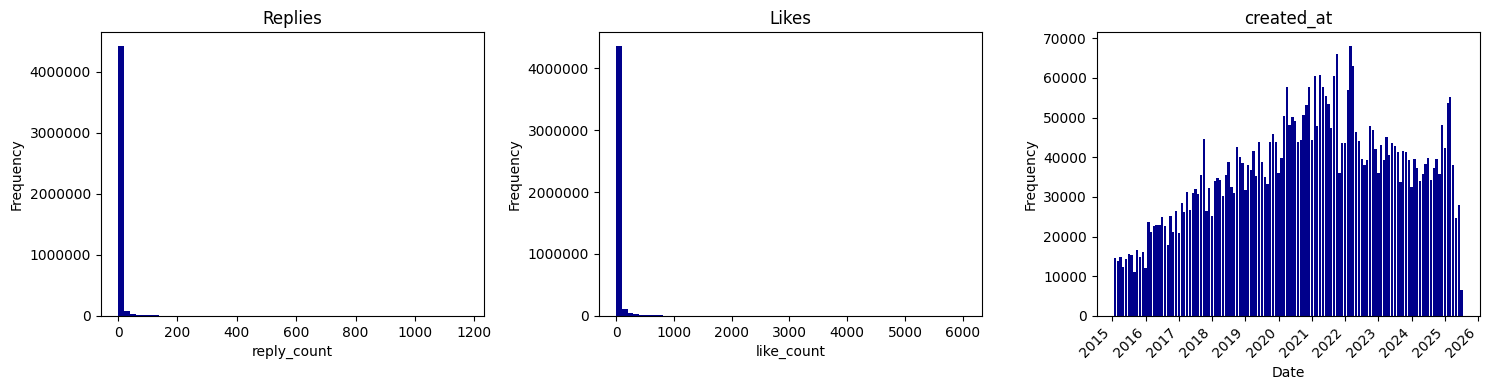

In [12]:
# Monthly tweet counts
monthly_counts = df.set_index('created_at').resample('ME').size().reset_index()
monthly_counts.columns = ['date', 'count']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Replies histogram ---
ax = axes[0]
replies = df['reply_count'].dropna()
replies_clipped = replies[replies <= replies.quantile(0.999)]
ax.hist(replies_clipped, bins=60, color=BLUE, edgecolor='none')
ax.set_title('Replies')
ax.set_xlabel('reply_count')
ax.set_ylabel('Frequency')
ax.ticklabel_format(axis='y', style='plain')

# --- Likes histogram ---
ax = axes[1]
likes = df['like_count'].dropna()
likes_clipped = likes[likes <= likes.quantile(0.999)]
ax.hist(likes_clipped, bins=60, color=BLUE, edgecolor='none')
ax.set_title('Likes')
ax.set_xlabel('like_count')
ax.set_ylabel('Frequency')
ax.ticklabel_format(axis='y', style='plain')

# --- Monthly tweet count bar chart ---
ax = axes[2]
ax.bar(monthly_counts['date'], monthly_counts['count'],
       width=25, color=BLUE, edgecolor='none')
ax.set_title('created_at')
ax.set_xlabel('Date')
ax.set_ylabel('Frequency')
ax.xaxis.set_major_locator(plt.matplotlib.dates.YearLocator())
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('results/twitter/plots/descriptives.png', dpi=150, bbox_inches='tight')
plt.show()

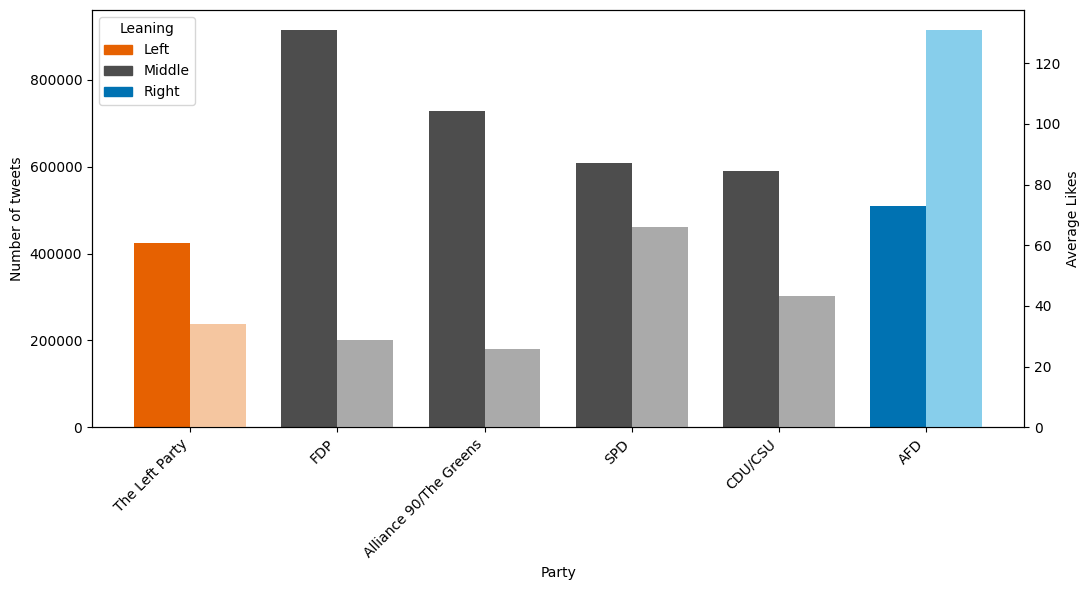

In [13]:
import matplotlib.patches as mpatches

# Load party / leaning / engagement columns
df_party = pd.read_csv(
    DATA_PATH,
    usecols=["party", "leaning", "like_count"],
    low_memory=False
)

agg = (
    df_party
    .groupby(["leaning", "party"])
    .agg(tweet_count=("like_count", "count"),
         avg_likes=("like_count", "mean"))
    .reset_index()
)

# Sort left → middle → right, then by tweet count descending within group
leaning_order = {"left": 0, "middle": 1, "right": 2}
agg["_ord"] = agg["leaning"].map(leaning_order)
agg = agg.sort_values(["_ord", "tweet_count"], ascending=[True, False]).reset_index(drop=True)

DARK  = {"left": "#E66101", "middle": "#4D4D4D", "right": "#0072B2"}
LIGHT = {"left": "#F5C6A0", "middle": "#AAAAAA", "right": "#87CEEB"}

parties = agg["party"].tolist()
n = len(parties)
x = np.arange(n)
width = 0.38

fig, ax1 = plt.subplots(figsize=(11, 6))
ax2 = ax1.twinx()

for i, row in agg.iterrows():
    ax1.bar(i - width / 2, row["tweet_count"], width,
            color=DARK[row["leaning"]], edgecolor="none")
    ax2.bar(i + width / 2, row["avg_likes"], width,
            color=LIGHT[row["leaning"]], edgecolor="none")

ax1.set_ylabel("Number of tweets")
ax2.set_ylabel("Average Likes")
ax1.set_xticks(x)
ax1.set_xticklabels(parties, rotation=45, ha="right")
ax1.set_xlabel("Party")
ax1.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)

legend_handles = [
    mpatches.Patch(color=DARK["left"],   label="Left"),
    mpatches.Patch(color=DARK["middle"], label="Middle"),
    mpatches.Patch(color=DARK["right"],  label="Right"),
]
ax1.legend(handles=legend_handles, title="Leaning", loc="upper left")

plt.tight_layout()
plt.savefig("results/twitter/plots/party_descriptives.png", dpi=150, bbox_inches="tight")
plt.show()

N annotators: 47
Gender
Male      35
Female    12


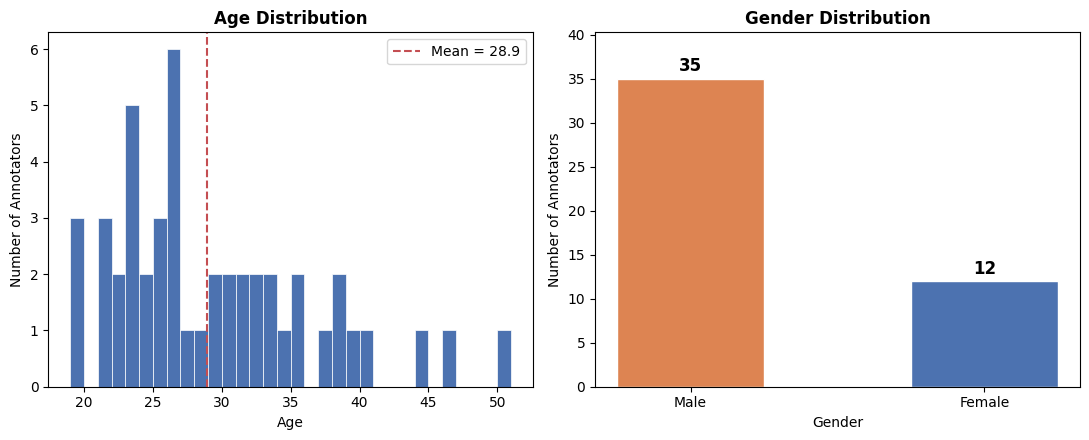

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# --- Load annotator data ---
ANNOTATOR_PATH = "validation/keyword/PRODEMINFO_-_German_clean.csv"
df_ann = pd.read_csv(ANNOTATOR_PATH, sep=";", usecols=["Age", "Gender"])
# First row is the German question label — drop it
df_ann = df_ann[~df_ann["Age"].astype(str).str.contains("alt sind", na=False)].copy()
df_ann["Age"] = pd.to_numeric(df_ann["Age"], errors="coerce")
# Prolific encoding: 1 = Female, 3 = Non-binary/Diverse
df_ann["Gender"] = df_ann["Gender"].map({"1": "Male", "3": "Female"})
df_ann = df_ann.dropna(subset=["Age", "Gender"])
print(f"N annotators: {len(df_ann)}")
print(df_ann["Gender"].value_counts().to_string())

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Age histogram
ax = axes[0]
ax.hist(df_ann["Age"], bins=range(int(df_ann["Age"].min()), int(df_ann["Age"].max()) + 2),
        color="#4C72B0", edgecolor="white", linewidth=0.5)
ax.set_title("Age Distribution", fontweight="bold")
ax.set_xlabel("Age")
ax.set_ylabel("Number of Annotators")
ax.axvline(df_ann["Age"].mean(), color="#C44E52", linestyle="--", linewidth=1.5,
           label=f"Mean = {df_ann['Age'].mean():.1f}")
ax.legend(fontsize=10)

# Gender bar chart
ax = axes[1]
gender_counts = df_ann["Gender"].value_counts().reindex(["Male", "Female"])
colors = ["#DD8452", "#4C72B0"]
bars = ax.bar(gender_counts.index, gender_counts.values, color=colors,
              edgecolor="white", width=0.5)
for bar, val in zip(bars, gender_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
            str(val), ha="center", va="bottom", fontweight="bold", fontsize=12)
ax.set_title("Gender Distribution", fontweight="bold")
ax.set_xlabel("Gender")
ax.set_ylabel("Number of Annotators")
ax.set_ylim(0, gender_counts.max() * 1.15)

#fig.suptitle(f"Annotator Demographics  (N = {len(df_ann)})", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("results/twitter/plots/annotator_demographics.png", dpi=150, bbox_inches="tight")
plt.show()